In [1]:
import wandb
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from tikzplotlib import save as tikz_save
from concurrent.futures import ThreadPoolExecutor, as_completed
import math
import re
from concurrent.futures import ThreadPoolExecutor

GOLD = "#FFB000"
PURPLE = "#785EF0"
ORANGE = "#FE6100"
BLU = "#648FFF"
PINK = "#DC267F"
BLACK = "black"

In [2]:
api = wandb.Api()
runs = list(api.runs(
    "alessandro-montenegro-polimi/forzaroma-rt-ppo-ant",
    filters={"tags": {"$in": ["baseline", "wppo_1", "wppo_3", "wppo_3_v2"]}, "state": "finished"},
    per_page=100
))

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/ricca/.netrc.


In [3]:
# GET ALL RUNS IN PARALLEL

def fetch_run(run):
    hist = run.history(
        keys=["eval/mean_reward", "global_step"],
        samples=500,
        pandas=True
    )
    hist["seed"] = run.config["experiment"]["seed"]
    hist["group"] = run.config["group_name"]

    # pick the first matching tag from your target list
    target_tags = {"baseline", "wppo_1", "wppo_3", "wppo_3_v2"}
    matched = next((t for t in run.tags if t in target_tags), "unknown")
    hist["tag"] = matched

    return hist

with ThreadPoolExecutor(max_workers=8) as executor:
    records = list(executor.map(fetch_run, runs))

df = pd.concat(records, ignore_index=True)

In [4]:
# PRINT RUNS

seed_counts = (
    df.groupby(["tag", "group"])["seed"]
    .nunique()
    .reset_index()
    .rename(columns={"seed": "seeds"})
)

tag_order = ["baseline", "wppo_1", "wppo_3", "wppo_3_v2"]
SEP = "═" * 50

def extract_w(group_str):
    match = re.search(r"w=(\d+)", group_str)
    return int(match.group(1)) if match else float("inf")

def classify_row(group_str):
    """Return (order_idx, method) for sorting, or None if unmatched."""
    for i, (method, critic) in enumerate([
        ("BH", "ON"), ("BH", "OFF"), ("wPPO-N", "ON"), ("wPPO-N", "OFF")
    ]):
        if method in group_str and f"critic={critic}" in group_str:
            return i, method
    return None

for tag in tag_order:
    subset = seed_counts[seed_counts["tag"] == tag]
    if subset.empty:
        continue

    print(f"\n{SEP}\n  {tag}\n{SEP}")

    subset = subset.copy()
    subset["_w"] = subset["group"].map(extract_w)
    subset["_class"] = subset["group"].map(classify_row)

    matched   = subset[subset["_class"].notna()].copy()
    unmatched = subset[subset["_class"].isna()].copy()

    # Sort matched rows by w value, then by sub_order index
    matched["_order_idx"] = matched["_class"].map(lambda x: x[0])
    matched = matched.sort_values(["_w", "_order_idx"])

    prev_w = None
    for _, row in matched.iterrows():
        if prev_w is not None and row["_w"] != prev_w:
            print()
        print(f"{row.seeds:>2} seeds | {row['group']}")
        prev_w = row["_w"]

    for _, row in unmatched.sort_values("_w").iterrows():
        print(f"{row.seeds:>2} seeds | {row['group']}")


══════════════════════════════════════════════════
  baseline
══════════════════════════════════════════════════
10 seeds | PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10
 2 seeds | PPO 1x512=512 K=20 nb=16 B=32 nu=320 ns=20

══════════════════════════════════════════════════
  wppo_1
══════════════════════════════════════════════════
10 seeds | wPPO-BH w=2 critic=ON 1x512=512 K=10 nb=32 B=32 nu=320 ns=20
10 seeds | wPPO-N w=2 critic=ON 1x512=512 K=10 nb=32 B=32 nu=320 ns=20

 4 seeds | wPPO-BH w=4 critic=ON 1x512=512 K=10 nb=64 B=32 nu=640 ns=40

══════════════════════════════════════════════════
  wppo_3
══════════════════════════════════════════════════
10 seeds | wPPO-BH w=2 critic=ON 1x512=512 K=10 nb=16 B=64 nu=160 ns=20
10 seeds | wPPO-N w=2 critic=ON 1x512=512 K=10 nb=16 B=64 nu=160 ns=20

 8 seeds | wPPO-BH w=4 critic=ON 1x512=512 K=10 nb=16 B=128 nu=160 ns=40

══════════════════════════════════════════════════
  wppo_3_v2
══════════════════════════════════════════════════
10 see

In [15]:
# SET 1 (K and B fixed) ==========================================================================================================

set_1_w2 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo $\\omega=2$": {
        "group": "wPPO-N w=2 critic=ON 1x512=512 K=10 nb=32 B=32 nu=320 ns=20",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo $\\omega=2$": {
        "group": "wPPO-BH w=2 critic=ON 1x512=512 K=10 nb=32 B=32 nu=320 ns=20",
        "color": BLU,
        "linestyle": "solid",
    }
}

set_1_w4 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo: $\\omega=4$": {
        "group": "wPPO-N w=4 critic=ON 1x512=512 K=10 nb=64 B=32 nu=640 ns=40",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=4$": {
        "group": "wPPO-BH w=4 critic=ON 1x512=512 K=10 nb=64 B=32 nu=640 ns=40",
        "color": BLU,
        "linestyle": "solid",
    },
}


set_1_w8 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo: $\\omega=8$": {
        "group": "",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=8$": {
        "group": "",
        "color": BLU,
        "linestyle": "solid",
    },
}


In [16]:
# SET 2 (K and B fixed) ==========================================================================================================

set_2_w2 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\ppo (matching updates)": {
        "group": "PPO 1x512=512 K=20 nb=16 B=32 nu=320 ns=20",
        "color": BLACK,
        "linestyle": "dashed",
    },
    "\\uppo: $\\omega=2$": {
        "group": "wPPO-N w=2 critic=ON 1x512=512 K=10 nb=32 B=32 nu=320 ns=20",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=2$": {
        "group": "wPPO-BH w=2 critic=ON 1x512=512 K=10 nb=32 B=32 nu=320 ns=20",
        "color": BLU,
        "linestyle": "solid",
    }
}


set_2_w4 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\ppo (matching updates)": {
        "group": "",
        "color": BLACK,
        "linestyle": "dashed",
    },
    "\\uppo: $\\omega=4$": {
        "group": "wPPO-N w=4 critic=ON 1x512=512 K=10 nb=64 B=32 nu=640 ns=40",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=4$": {
        "group": "wPPO-BH w=4 critic=ON 1x512=512 K=10 nb=64 B=32 nu=640 ns=40",
        "color": BLU,
        "linestyle": "solid",
    },
}

set_2_w8 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\ppo (matching updates)": {
        "group": "",
        "color": BLACK,
        "linestyle": "dashed",
    },
    "\\uppo: $\\omega=8$": {
        "group": "",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=8$": {
        "group": "",
        "color": BLU,
        "linestyle": "solid",
    },
}


In [17]:
# SET 3 (K and nb fixed) ==========================================================================================================

set_3_w2 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo: $\\omega=2$": {
        "group": "wPPO-N w=2 critic=ON 1x512=512 K=10 nb=16 B=64 nu=160 ns=20",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=2$": {
        "group": "wPPO-BH w=2 critic=ON 1x512=512 K=10 nb=16 B=64 nu=160 ns=20",
        "color": BLU,
        "linestyle": "solid",
    }
}


set_3_w4 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo: $\\omega=4$": {
        "group": "",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=4$": {
        "group": "",
        "color": BLU,
        "linestyle": "solid",
    },
}

set_3_w8 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo: $\\omega=8$": {
        "group": "",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=8$": {
        "group": "",
        "color": BLU,
        "linestyle": "solid",
    },
}


In [18]:
# SET 4 (K and B and nb fixed) ==========================================================================================================

set_4_w2 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo: $\\omega=2$": {
        "group": "wPPO-N w=2 critic=ON 1x256=256 K=10 nb=16 B=32 nu=160 ns=20",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=2$": {
        "group": "wPPO-BH w=2 critic=ON 1x256=256 K=10 nb=16 B=32 nu=160 ns=20",
        "color": BLU,
        "linestyle": "solid",
    }
}


set_4_w4 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo: $\\omega=4$": {
        "group": "wPPO-N w=4 critic=ON 1x128=128 K=10 nb=16 B=32 nu=160 ns=40",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=4$": {
        "group": "wPPO-BH w=4 critic=ON 1x128=128 K=10 nb=16 B=32 nu=160 ns=40",
        "color": BLU,
        "linestyle": "solid",
    },
}

set_4_w8 = {
    "\\ppo": {
        "group": "PPO 1x512=512 K=10 nb=16 B=32 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
    "\\uppo: $\\omega=8$": {
        "group": "wPPO-N w=8 critic=ON 1x64=64 K=10 nb=16 B=32 nu=160 ns=80",
        "color": PINK,
        "linestyle": "solid",
    },
    "\\bhppo: $\\omega=8$": {
        "group": "wPPO-BH w=8 critic=ON 1x64=64 K=10 nb=16 B=32 nu=160 ns=80",
        "color": BLU,
        "linestyle": "solid",
    },
}


In [19]:
# debug ==========================================================================================================

debug = {
    "\\ppo": {
        "group": "PPO 4x1024=4096 K=10 nb=16 B=256 nu=160 ns=10",
        "color": BLACK,
        "linestyle": "solid",
    },
}

In [ ]:
# ── PLOT Configuration ────────────────────────────────────────────────────────────
SMOOTH_WINDOW = 10
N_COLS        = 3
SAVE          = False  # Set to False to only display

plot_configs = [
    (set_1_w2, "ant_set_1_w2.tex"),
    (set_1_w4, "ant_set_1_w4.tex"),
    (set_1_w8, "ant_set_1_w8.tex"),
    (set_2_w2, "ant_set_2_w2.tex"),
    (set_2_w4, "ant_set_2_w4.tex"),
    (set_2_w8, "ant_set_2_w8.tex"),
    (set_3_w2, "ant_set_3_w2.tex"),
    (set_3_w4, "ant_set_3_w4.tex"),
    (set_3_w8, "ant_set_3_w8.tex"),
    (set_4_w2, "ant_set_4_w2.tex"),
    (set_4_w4, "ant_set_4_w4.tex"),
    (set_4_w8, "ant_set_4_w8.tex"),
]

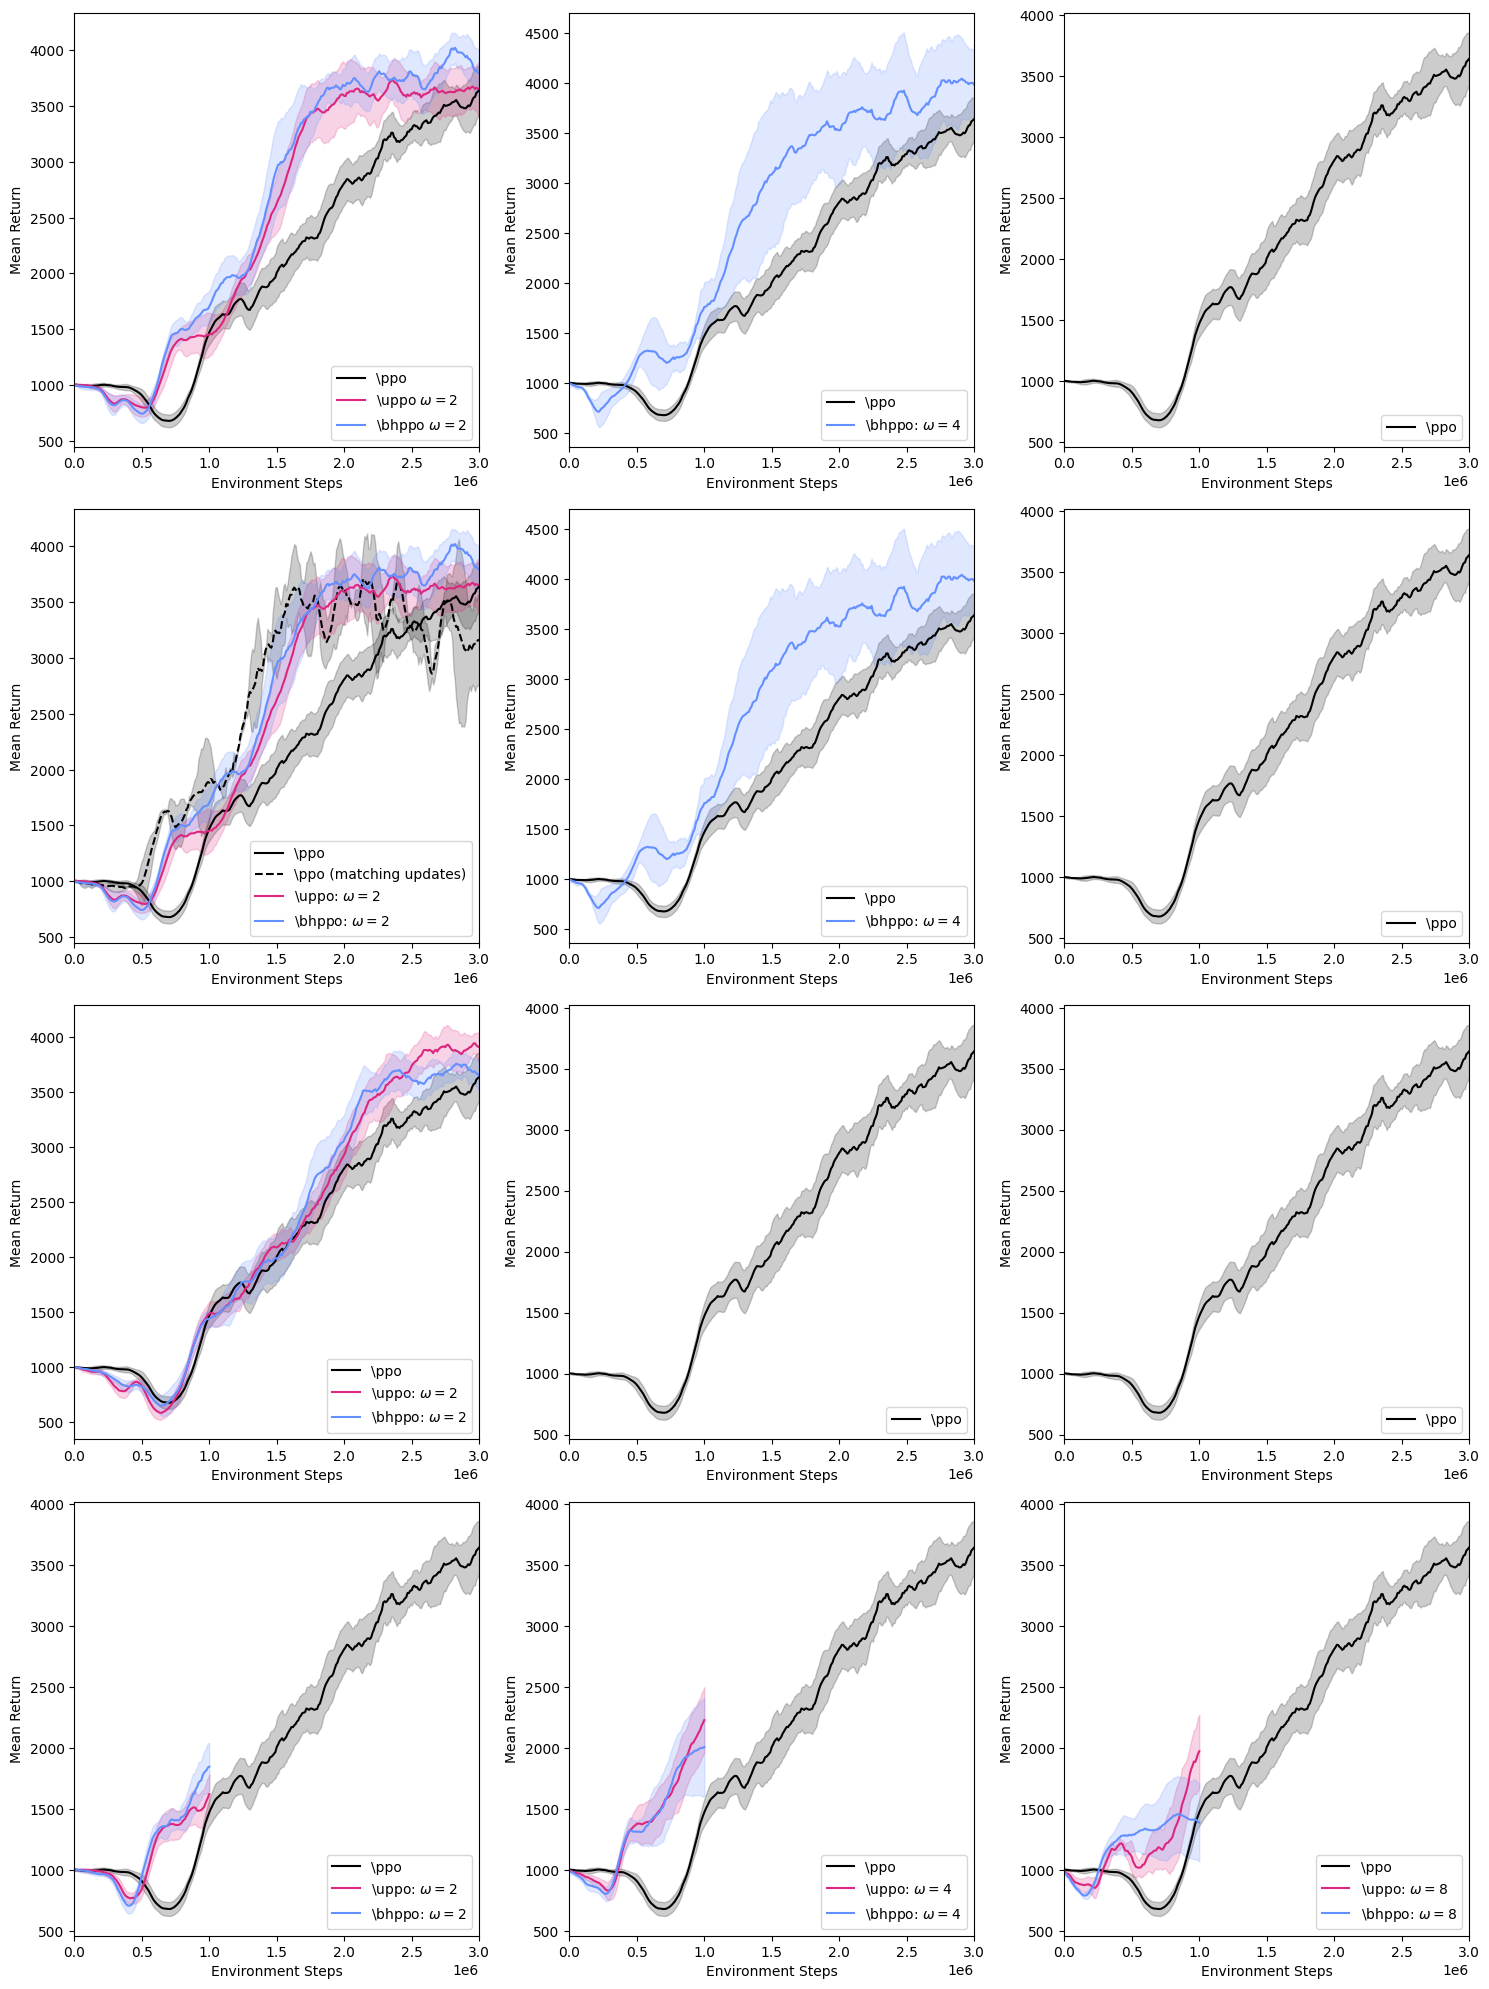

In [21]:
# PLOT ==========================================================================================================

# ── Preprocessing ────────────────────────────────────────────────────────────
df["reward_smooth"] = (
    df.groupby(["group", "seed"])["eval/mean_reward"]
    .transform(lambda x: x.rolling(SMOOTH_WINDOW, min_periods=1).mean())
)

# ── Plot grid ────────────────────────────────────────────────────────────────
n_plots = len(plot_configs)
n_rows  = math.ceil(n_plots / N_COLS)
fig, axes = plt.subplots(n_rows, N_COLS, figsize=(5 * N_COLS, 5 * n_rows))
axes_flat = np.array(axes).flatten()

for ax in axes_flat[n_plots:]:
    ax.set_visible(False)

# ── Draw each subplot ────────────────────────────────────────────────────────
for ax, (mapping, name_plot) in zip(axes_flat, plot_configs):
    for legend_name, cfg in mapping.items():
        group_df = df[df["group"] == cfg["group"]]
        if group_df.empty:
            continue

        pivot = group_df.groupby("global_step")["reward_smooth"]
        mean  = pivot.mean()
        ci95  = 1.96 * pivot.std() / np.sqrt(pivot.count())

        ax.plot(mean.index, mean.values,
                label=legend_name, color=cfg["color"], linestyle=cfg["linestyle"])
        ax.fill_between(mean.index, mean - ci95, mean + ci95,
                        alpha=0.2, color=cfg["color"])

    ax.set(xlabel="Environment Steps", ylabel="Mean Return", xlim=(0, 3_000_000))
    ax.legend(loc="lower right")

    if SAVE:
        tikz_save(name_plot, figure=fig)

fig.tight_layout()
plt.show()